# Kaggle Predict F1 Pit Stops: Preprocessing and EDA

This notebook is the first pass over the competition data. It is designed to run on Kaggle with data mounted at `/kaggle/input/competitions/playground-series-s6e5`, while also supporting a local `data/` directory.

Goals:
- Load `train.csv`, `test.csv`, and `sample_submission.csv`.
- Check schema, missing values, cardinality, duplicates, and target balance.
- Explore numerical and categorical feature relationships with `PitNextLap`.
- Compare train/test distributions to catch drift before modeling.
- Build reusable preprocessing helpers that avoid target leakage.

## 1. Data Loading and Setup


In [1]:
import os
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.frameon": False,
})

VIRIDIS_CMAP = "viridis"
VIRIDIS_COLORS = sns.color_palette("viridis", 8)
PRIMARY_COLOR = VIRIDIS_COLORS[4]
SECONDARY_COLOR = VIRIDIS_COLORS[2]
ACCENT_COLOR = VIRIDIS_COLORS[6]
RANDOM_STATE = 42


In [2]:
def find_data_dir() -> Path:
    candidates = [
        Path("/kaggle/input/competitions/playground-series-s6e5"),
        Path("/kaggle/input/playground-series-s6e5"),
        Path("../input/competitions/playground-series-s6e5"),
        Path("../input/playground-series-s6e5"),
        Path("data"),
        Path("../data"),
        Path("."),
    ]
    for path in candidates:
        if (path / "train.csv").exists() and (path / "test.csv").exists():
            return path
    raise FileNotFoundError("Could not find train.csv and test.csv. Update DATA_DIR manually.")


DATA_DIR = find_data_dir()
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR, OUTPUT_DIR


(PosixPath('/kaggle/input/competitions/playground-series-s6e5'),
 PosixPath('/kaggle/working'))

### 1.2 Load Competition Files


In [3]:
def reduce_memory_usage(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast numeric columns to make repeated EDA/modeling faster on Kaggle."""
    out = df.copy()
    for col in out.columns:
        col_type = out[col].dtype
        if pd.api.types.is_integer_dtype(col_type):
            out[col] = pd.to_numeric(out[col], downcast="integer")
        elif pd.api.types.is_float_dtype(col_type):
            out[col] = pd.to_numeric(out[col], downcast="float")
        elif pd.api.types.is_object_dtype(col_type):
            nunique = out[col].nunique(dropna=False)
            if nunique / max(len(out), 1) < 0.5:
                out[col] = out[col].astype("category")
    return out


train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

train = reduce_memory_usage(train)
test = reduce_memory_usage(test)

print(f"train shape: {train.shape}")
print(f"test shape: {test.shape}")
print(f"sample submission shape: {sample_submission.shape}")
train.head()


train shape: (439140, 16)
test shape: (188165, 15)
sample submission shape: (188165, 2)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.490997,-7.564000,21.018999,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095001,-32.617001,-223.207001,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945000,-7.540000,-100.528999,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361000,-7.324000,-7.324000,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.877998,8.965000,-14.139000,0.361111,3.0,0.0


In [4]:
TARGET = "PitNextLap"
ID_COL = "id"

feature_cols = [c for c in train.columns if c not in [TARGET]]
categorical_cols = train[feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

print("Target:", TARGET)
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Target: PitNextLap
Categorical columns: ['Driver', 'Compound', 'Race']
Numeric columns: ['id', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']


## 2. Data Quality Review


In [5]:
def dataframe_overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    overview = pd.DataFrame({
        "dataset": name,
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean().mul(100),
        "unique": df.nunique(dropna=False),
        "memory_mb": df.memory_usage(deep=True).div(1024 ** 2),
    })
    return overview.sort_values(["missing_pct", "unique"], ascending=[False, False])


overview = pd.concat([
    dataframe_overview(train, "train"),
    dataframe_overview(test, "test"),
])
overview


,dataset,dtype,missing,missing_pct,unique,memory_mb
id,train,int32,0.0,0.0,439140.0,1.675186
Cumulative_Degradation,train,float32,0.0,0.0,87482.0,1.675186
LapTime_Delta,train,float32,0.0,0.0,44485.0,1.675186
LapTime (s),train,float32,0.0,0.0,37700.0,1.675186
RaceProgress,train,float32,0.0,0.0,1618.0,1.675186
Driver,train,category,0.0,0.0,887.0,0.913834
LapNumber,train,int8,0.0,0.0,78.0,0.418797
TyreLife,train,float32,0.0,0.0,78.0,1.675186
Position_Change,train,float32,0.0,0.0,37.0,1.675186
Race,train,category,0.0,0.0,26.0,0.421549


In [6]:
quality_checks = pd.DataFrame({
    "check": [
        "train duplicated rows",
        "test duplicated rows",
        "train duplicated id",
        "test duplicated id",
        "train/test id overlap",
    ],
    "value": [
        int(train.duplicated().sum()),
        int(test.duplicated().sum()),
        int(train[ID_COL].duplicated().sum()) if ID_COL in train else np.nan,
        int(test[ID_COL].duplicated().sum()) if ID_COL in test else np.nan,
        int(pd.Index(train[ID_COL]).intersection(test[ID_COL]).shape[0]) if ID_COL in train and ID_COL in test else np.nan,
    ],
})
quality_checks


,check,value
0,train duplicated rows,0
1,test duplicated rows,0
2,train duplicated id,0
3,test duplicated id,0
4,train/test id overlap,0


In [7]:
train.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,439140.0,NaN,NaN,NaN,219569.5,126768.942943,0.0,109784.75,219569.5,329354.25,439139.0
Driver,439140,887,MAS,1682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Compound,439140,5,MEDIUM,211141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Race,439140,26,Dutch Grand Prix,24462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,439140.0,NaN,NaN,NaN,2023.523544,1.02493,2022.0,2023.0,2024.0,2024.0,2025.0
PitStop,439140.0,NaN,NaN,NaN,0.136118,0.342915,0.0,0.0,0.0,0.0,1.0
LapNumber,439140.0,NaN,NaN,NaN,23.105909,16.958261,1.0,9.0,19.0,36.0,78.0
Stint,439140.0,NaN,NaN,NaN,1.789113,0.950194,1.0,1.0,2.0,2.0,8.0
TyreLife,439140.0,NaN,NaN,NaN,14.158231,9.801338,1.0,6.0,12.0,20.0,77.0
Position,439140.0,NaN,NaN,NaN,9.630339,5.27877,1.0,5.0,10.0,14.0,20.0


### 2.1 Current Run Insights

From the saved notebook run:

- Train shape is `439,140 x 16`; test shape is `188,165 x 15`.
- No missing values were detected in train or test.
- There are no duplicated rows, no duplicated IDs, and no train/test ID overlap.
- `Driver` is high-cardinality (`887` train values, `801` test values); `Compound` has `5` values and `Race` has `26` values.
- Test has no unseen categorical values, but train has `86` drivers not present in test. This is useful when deciding how aggressively to encode driver identity.

These checks suggest the first modeling focus should be feature signal and validation design, not data cleaning.


## 3. Target Analysis

`PitNextLap` is the target. We expect a class imbalance because most laps are not followed by a pit stop.


,count,pct
PitNextLap,,
0.0,351759,0.801018
1.0,87381,0.198982


Positive rate: 0.1990


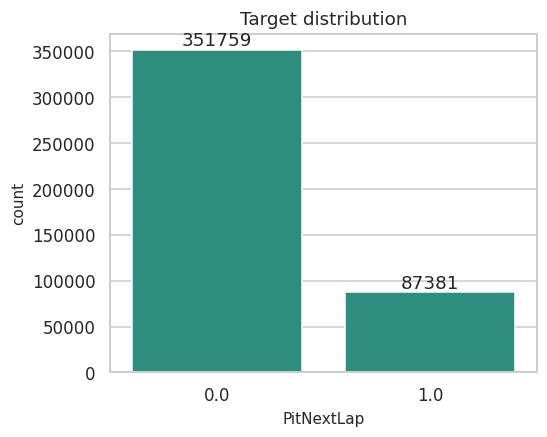

In [8]:
target_counts = train[TARGET].value_counts().sort_index()
target_rate = train[TARGET].mean()

display(pd.DataFrame({"count": target_counts, "pct": target_counts / len(train)}))
print(f"Positive rate: {target_rate:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=train, x=TARGET, color=PRIMARY_COLOR, ax=ax)
ax.set_title("Target distribution")
ax.bar_label(ax.containers[0])
plt.show()


### 3.1 Target Insights

The current run shows `PitNextLap = 1` for `87,381` rows, or about `19.90%` of training data.

Implications:

- Use stratified validation splits so each fold keeps the same pit-next-lap rate.
- Prefer probability metrics such as ROC AUC, PR AUC, or log loss over raw accuracy.
- Check calibration before submission because Kaggle expects likelihood predictions, not just class labels.


## 4. Feature Exploration


### 4.1 Categorical Features


In [9]:
def categorical_summary(df: pd.DataFrame, columns: list[str], target: str) -> pd.DataFrame:
    rows = []
    for col in columns:
        stats = df.groupby(col, observed=True)[target].agg(["count", "mean"]).reset_index()
        stats["feature"] = col
        stats = stats.rename(columns={col: "value", "mean": "target_rate"})
        stats["global_rate_diff"] = stats["target_rate"] - df[target].mean()
        rows.append(stats[["feature", "value", "count", "target_rate", "global_rate_diff"]])
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


cat_summary = categorical_summary(train, categorical_cols, TARGET)
cat_summary.sort_values(["feature", "count"], ascending=[True, False]).head(40)


,feature,value,count,target_rate,global_rate_diff
889,Compound,MEDIUM,211141,0.101131,-0.097851
887,Compound,HARD,170518,0.327537,0.128555
890,Compound,SOFT,38744,0.193475,-0.005507
888,Compound,INTERMEDIATE,17382,0.152284,-0.046698
891,Compound,WET,1355,0.025092,-0.173890
830,Driver,MAS,1682,0.231272,0.032290
849,Driver,RAI,1669,0.242660,0.043678
8,Driver,BAR,1656,0.219807,0.020825
19,Driver,BUT,1655,0.245317,0.046335
792,Driver,FIS,1651,0.219867,0.020885


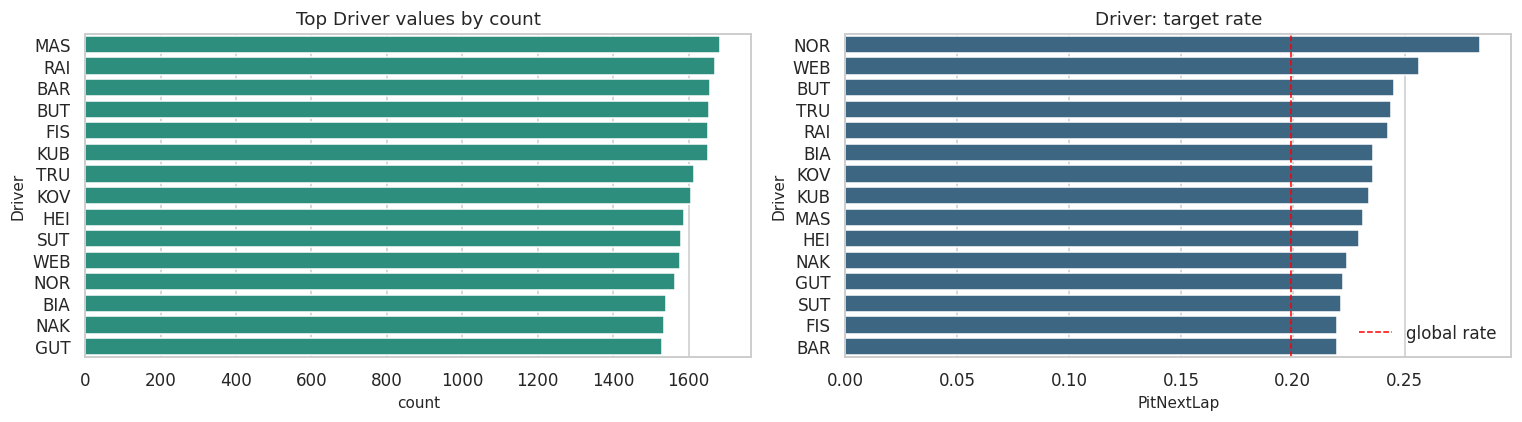

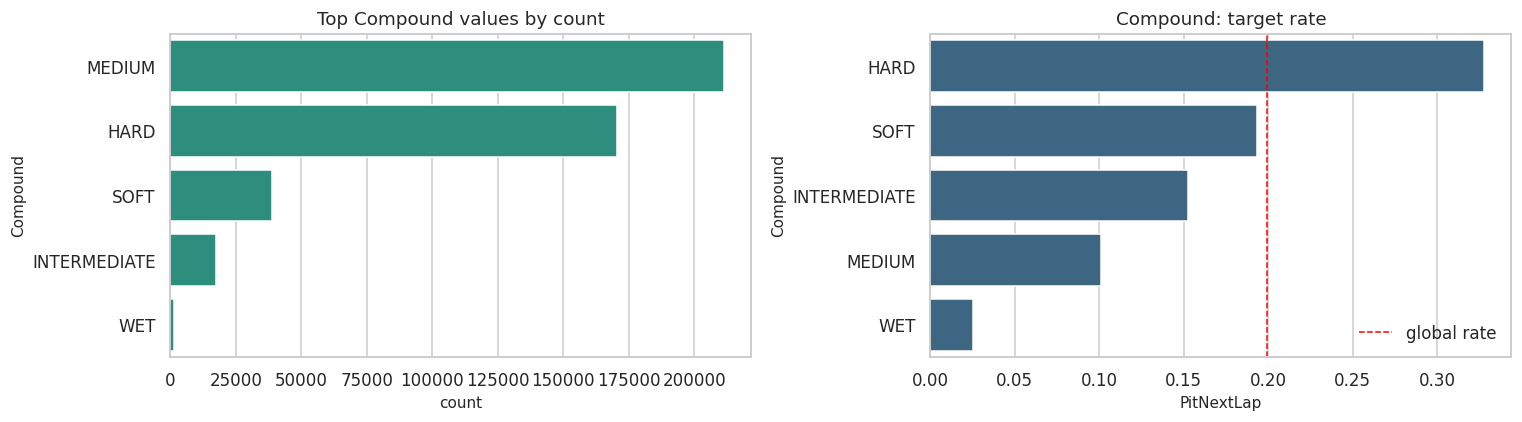

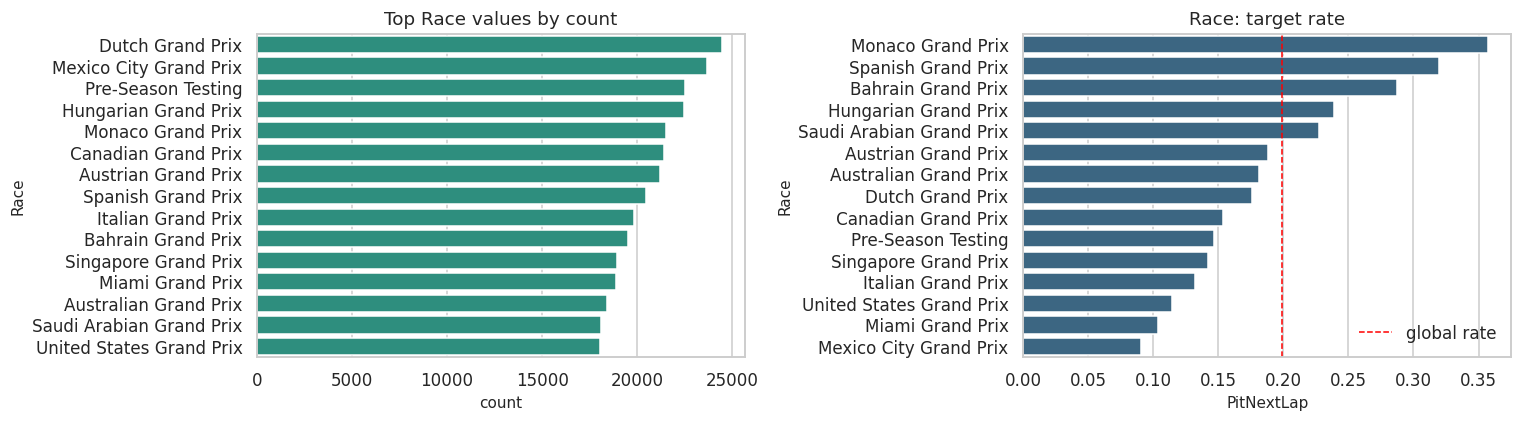

In [10]:
for col in categorical_cols:
    top_values = train[col].value_counts().head(15).index
    plot_df = train[train[col].isin(top_values)].copy()
    order = plot_df.groupby(col, observed=True)[TARGET].mean().sort_values(ascending=False).index
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.countplot(data=plot_df, y=col, order=top_values, color=PRIMARY_COLOR, ax=axes[0])
    axes[0].set_title(f"Top {col} values by count")
    
    sns.barplot(data=plot_df, y=col, x=TARGET, order=order, estimator=np.mean, errorbar=None, color=SECONDARY_COLOR, ax=axes[1])
    axes[1].axvline(train[TARGET].mean(), color="red", linestyle="--", linewidth=1, label="global rate")
    axes[1].set_title(f"{col}: target rate")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


### 4.1.1 Compound Strategy Signal

The saved run shows a strong compound-level relationship with the target:

- `HARD`: about `32.75%` pit-next-lap rate
- `SOFT`: about `19.35%`
- `INTERMEDIATE`: about `15.23%`
- `MEDIUM`: about `10.11%`
- `WET`: about `2.51%`

This does not mean hard tyres directly cause pit stops. It likely reflects stint timing, race phase, and strategy patterns. The deeper question is whether compound still matters after controlling for tyre life, stint, and race progress.


### 4.2 Numerical Features

The raw description suggests a few long-tailed lap-time and degradation features. We inspect both distributions and target-rate trends.


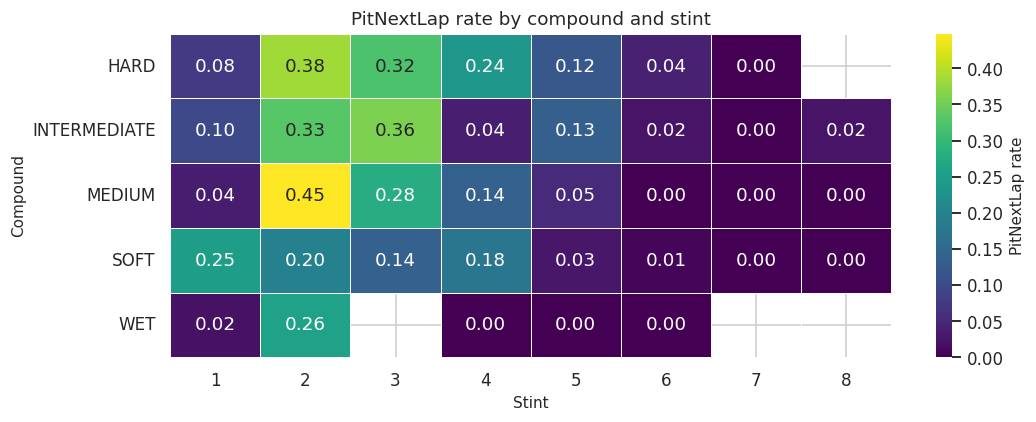

,Compound,Stint,count,mean
0,HARD,1,18098,0.075146
1,HARD,2,98535,0.384432
2,HARD,3,47055,0.320370
3,HARD,4,6059,0.238323
4,HARD,5,745,0.122148
5,HARD,6,24,0.041667
6,HARD,7,2,0.000000
7,INTERMEDIATE,1,10105,0.099654
8,INTERMEDIATE,2,2397,0.329996
9,INTERMEDIATE,3,2046,0.359726


In [11]:
# Deep dive: compound signal conditional on stint.
compound_stint = (
    train.groupby(["Compound", "Stint"], observed=True)[TARGET]
    .agg(["count", "mean"])
    .reset_index()
)

compound_stint_pivot = compound_stint.pivot(index="Compound", columns="Stint", values="mean")
compound_stint_counts = compound_stint.pivot(index="Compound", columns="Stint", values="count")

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    compound_stint_pivot,
    annot=True,
    fmt=".2f",
    cmap=VIRIDIS_CMAP,
    linewidths=0.5,
    cbar_kws={"label": "PitNextLap rate"},
    ax=ax,
)
ax.set_title("PitNextLap rate by compound and stint")
plt.tight_layout()
plt.show()

compound_stint.sort_values(["Compound", "Stint"])


In [12]:
numeric_for_eda = [c for c in numeric_cols if c != ID_COL]

num_summary = train[numeric_for_eda + [TARGET]].agg(["count", "mean", "std", "min", "median", "max"]).T
num_summary["skew"] = train[numeric_for_eda + [TARGET]].skew(numeric_only=True)
num_summary


,count,mean,std,min,median,max,skew
Year,439140.0,2023.523544,1.024930,2022.000000,2024.000000,2025.000000,-0.000611
PitStop,439140.0,0.136118,0.342915,0.000000,0.000000,1.000000,2.122297
LapNumber,439140.0,23.105909,16.958261,1.000000,19.000000,78.000000,0.645965
Stint,439140.0,1.789113,0.950194,1.000000,2.000000,8.000000,1.185479
TyreLife,439140.0,14.158231,9.801338,1.000000,12.000000,77.000000,1.032448
Position,439140.0,9.630339,5.278770,1.000000,10.000000,20.000000,0.070098
LapTime (s),439140.0,90.948753,19.770432,67.694000,90.521004,2507.606934,80.334335
LapTime_Delta,439140.0,-3.770040,43.910587,-2403.895020,-0.295000,2423.931885,-40.855064
Cumulative_Degradation,439140.0,-25.721764,54.755814,-274.563995,-20.993999,2412.025879,3.191501
RaceProgress,439140.0,0.337661,0.253286,0.012821,0.269231,1.000000,0.699950


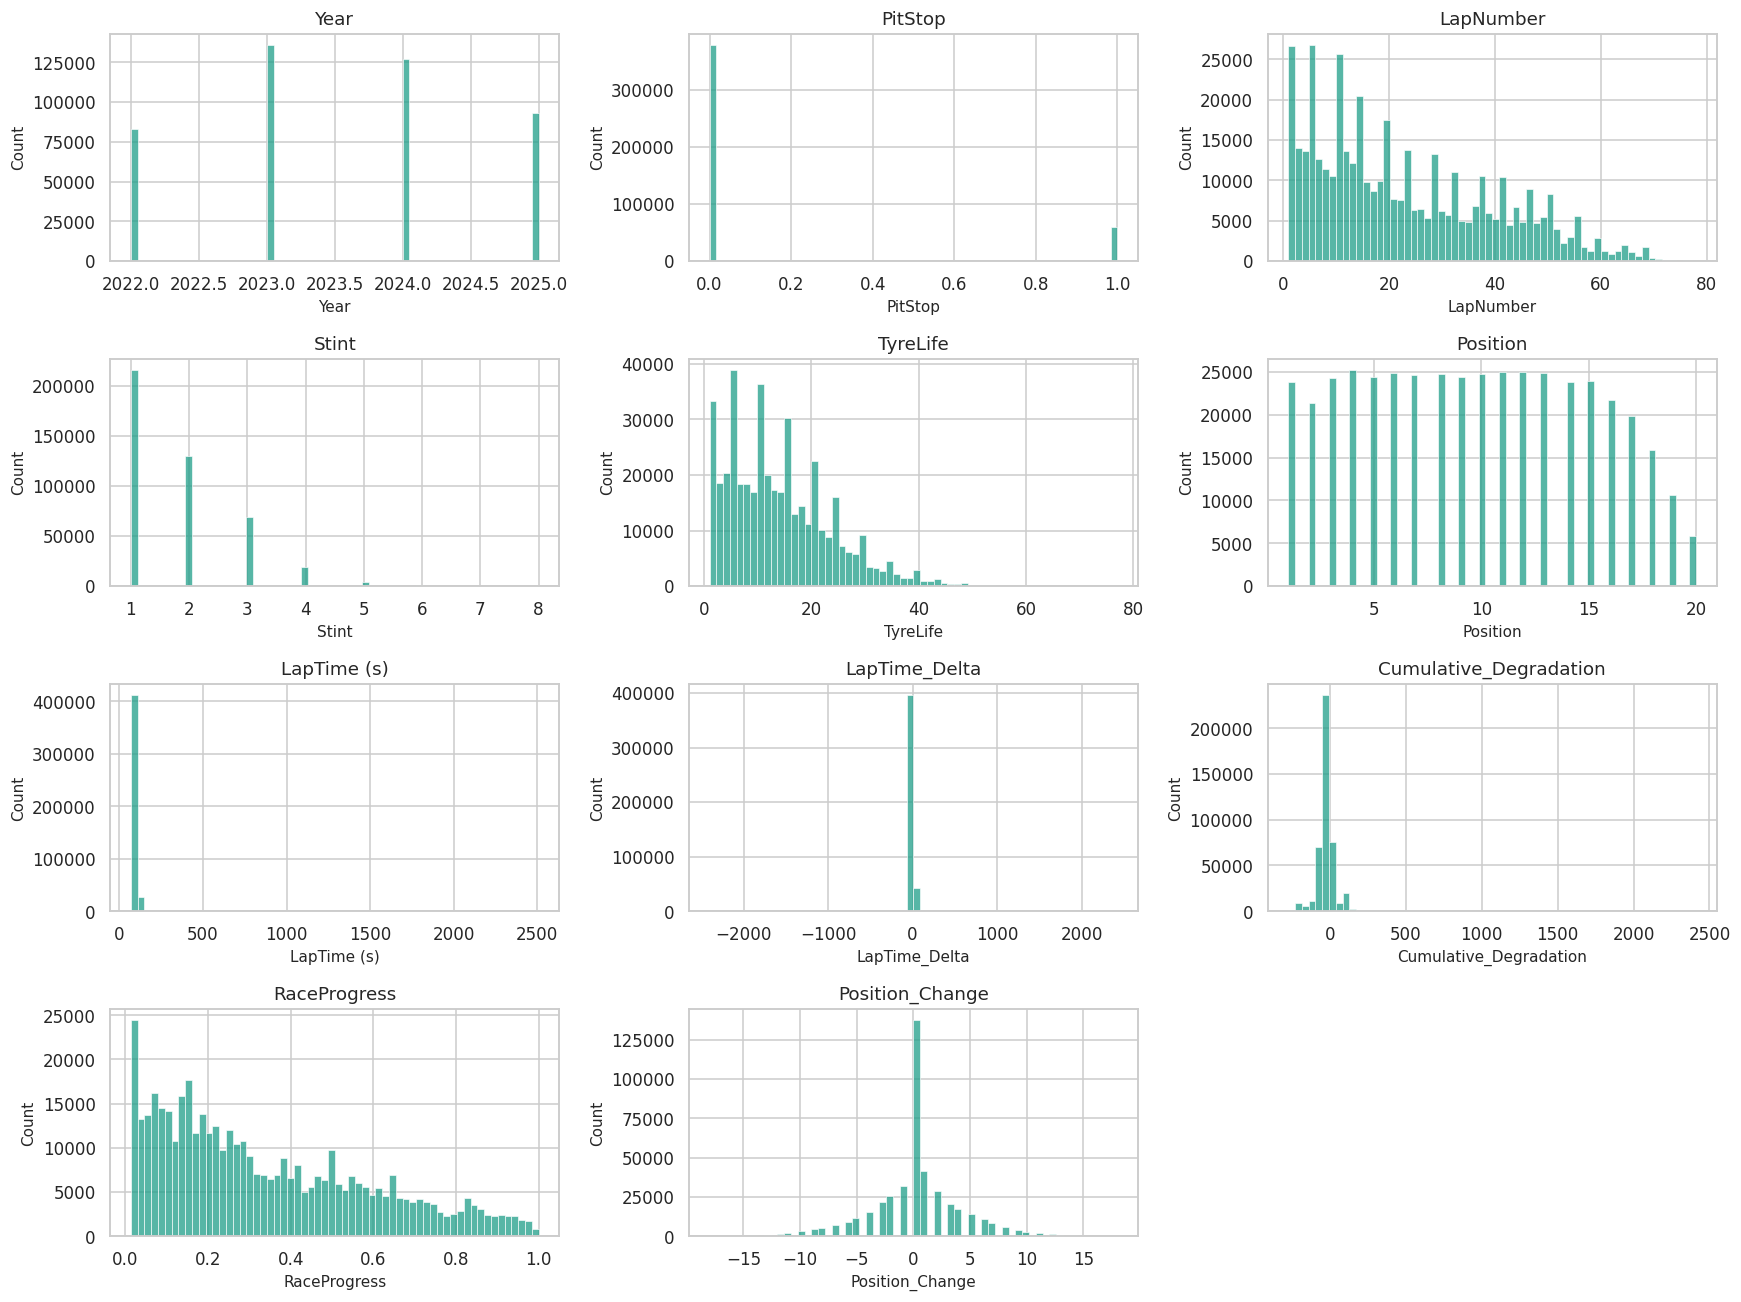

In [13]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_for_eda) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, max(4, 3 * n_rows)))
axes = np.ravel(axes)

for ax, col in zip(axes, numeric_for_eda):
    sns.histplot(train[col], bins=60, kde=False, color=PRIMARY_COLOR, ax=ax)
    ax.set_title(col)

for ax in axes[len(numeric_for_eda):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


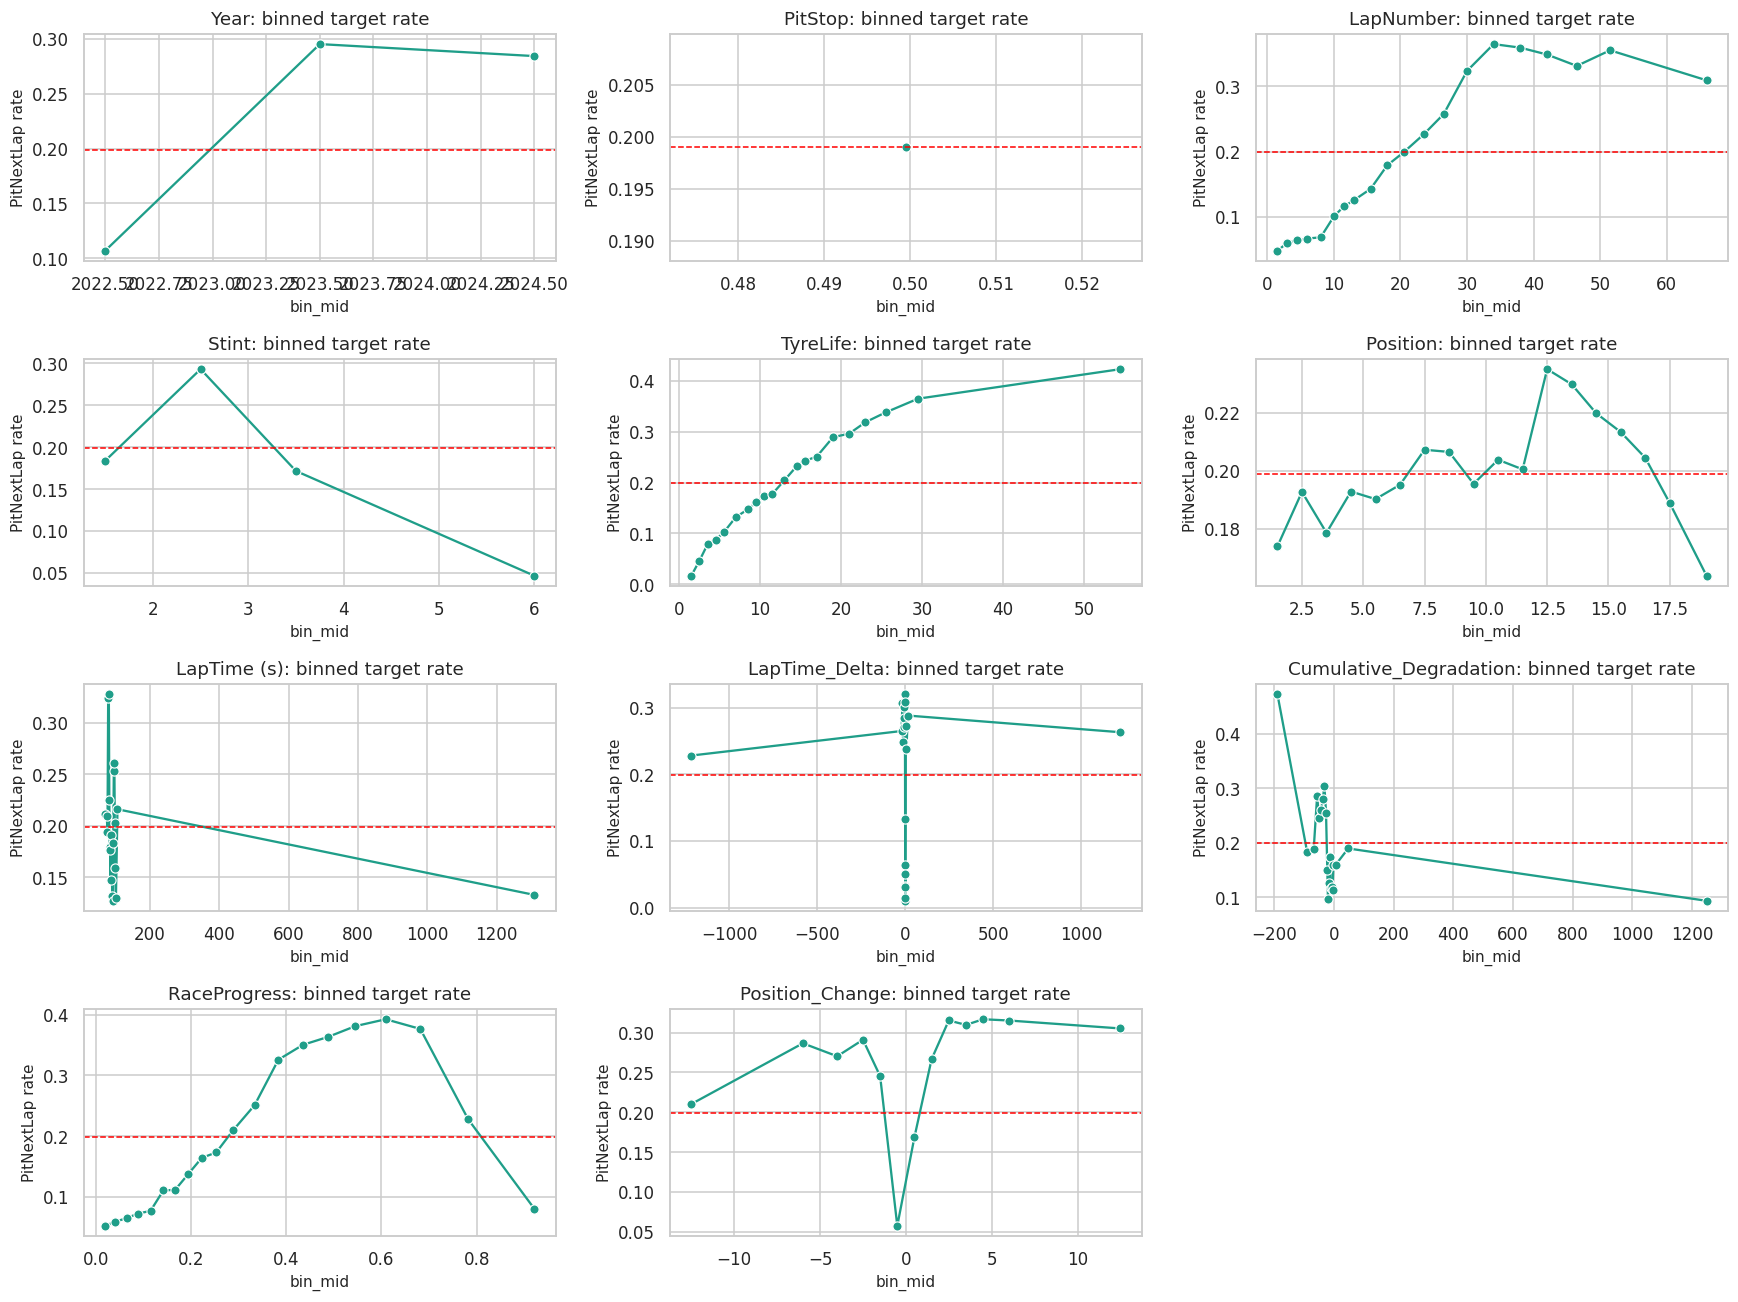

In [14]:
def binned_target_rate(df: pd.DataFrame, col: str, target: str, bins: int = 20) -> pd.DataFrame:
    tmp = df[[col, target]].copy()
    tmp["bin"] = pd.qcut(tmp[col], q=bins, duplicates="drop")
    out = tmp.groupby("bin", observed=True)[target].agg(["count", "mean"]).reset_index()
    out["bin_mid"] = out["bin"].apply(lambda x: x.mid).astype(float)
    return out


n_cols = 3
n_rows = int(np.ceil(len(numeric_for_eda) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, max(4, 3 * n_rows)))
axes = np.ravel(axes)

for ax, col in zip(axes, numeric_for_eda):
    rate_df = binned_target_rate(train, col, TARGET, bins=20)
    sns.lineplot(data=rate_df, x="bin_mid", y="mean", marker="o", color=PRIMARY_COLOR, ax=ax)
    ax.axhline(train[TARGET].mean(), color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{col}: binned target rate")
    ax.set_ylabel("PitNextLap rate")

for ax in axes[len(numeric_for_eda):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


### 4.2.1 Tyre Life and Race Progress Interaction

`TyreLife` and `RaceProgress` are likely more informative together than separately. A tyre age that is normal early in a race can be strategically different late in a race. This heatmap checks whether pit probability concentrates in specific tyre-age and race-progress zones.


## 5. Outlier and Event Review

A few fields can contain extreme race-event values. For tree models, clipping is often optional. For linear models, neural nets, or scaled distance-based models, clipping can help.


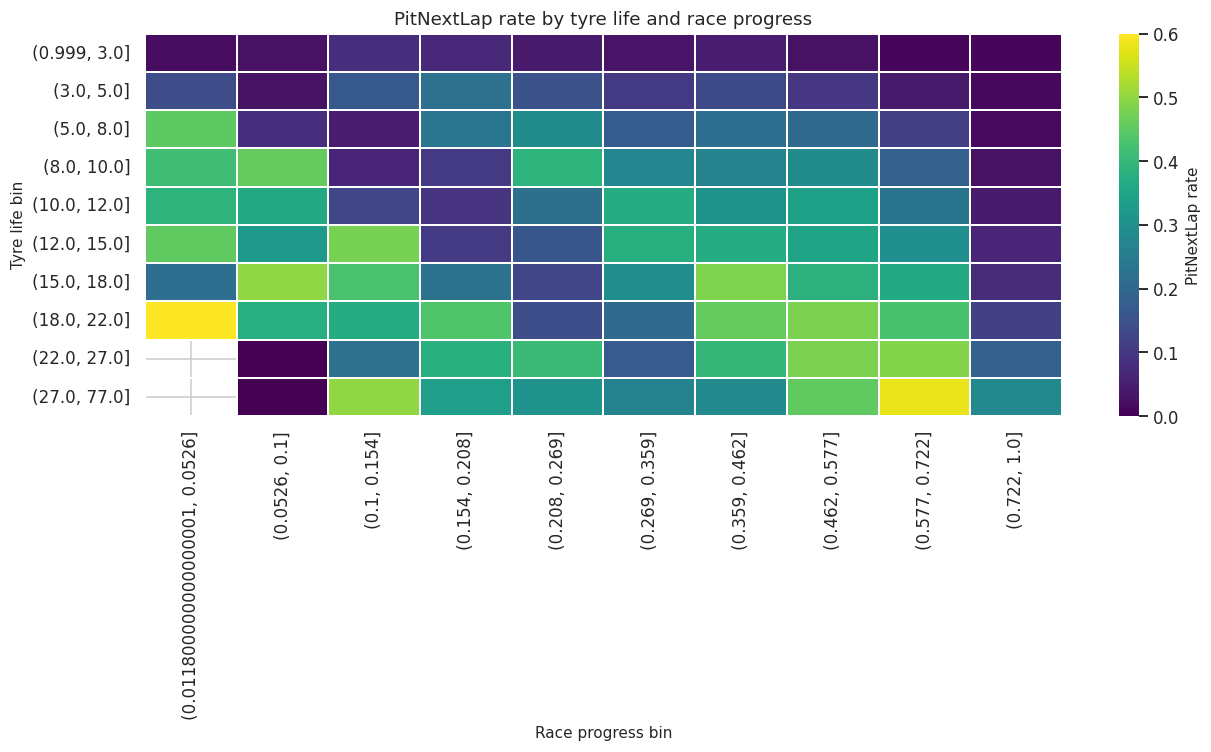

In [15]:
# Deep dive: target rate across tyre age and race progress.
interaction_df = train[["TyreLife", "RaceProgress", TARGET]].copy()
interaction_df["TyreLife_bin"] = pd.qcut(interaction_df["TyreLife"], q=10, duplicates="drop")
interaction_df["RaceProgress_bin"] = pd.qcut(interaction_df["RaceProgress"], q=10, duplicates="drop")

interaction_rate = interaction_df.pivot_table(
    index="TyreLife_bin",
    columns="RaceProgress_bin",
    values=TARGET,
    aggfunc="mean",
    observed=True,
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    interaction_rate,
    cmap=VIRIDIS_CMAP,
    linewidths=0.25,
    cbar_kws={"label": "PitNextLap rate"},
    ax=ax,
)
ax.set_title("PitNextLap rate by tyre life and race progress")
ax.set_xlabel("Race progress bin")
ax.set_ylabel("Tyre life bin")
plt.tight_layout()
plt.show()


In [16]:
def outlier_table(df: pd.DataFrame, columns: list[str], q_low: float = 0.001, q_high: float = 0.999) -> pd.DataFrame:
    rows = []
    for col in columns:
        low = df[col].quantile(q_low)
        high = df[col].quantile(q_high)
        rows.append({
            "feature": col,
            "min": df[col].min(),
            f"q{q_low}": low,
            "median": df[col].median(),
            f"q{q_high}": high,
            "max": df[col].max(),
            "below_low": int((df[col] < low).sum()),
            "above_high": int((df[col] > high).sum()),
        })
    return pd.DataFrame(rows)


outlier_table(train, numeric_for_eda).sort_values("above_high", ascending=False)


,feature,min,q0.001,median,q0.999,max,below_low,above_high
7,LapTime_Delta,-2403.895020,-63.238998,-0.295000,49.362582,2423.931885,438,440
10,Position_Change,-18.000000,-15.000000,0.000000,14.000000,18.000000,404,438
6,LapTime (s),67.694000,69.631276,90.521004,146.673996,2507.606934,440,437
4,TyreLife,1.000000,1.000000,12.000000,61.000000,77.000000,0,428
9,RaceProgress,0.012821,0.012821,0.269231,0.986111,1.000000,0,418
8,Cumulative_Degradation,-274.563995,-262.619931,-20.993999,147.345993,2412.025879,440,395
2,LapNumber,1.000000,1.000000,19.000000,71.000000,78.000000,0,332
3,Stint,1.000000,1.000000,2.000000,6.000000,8.000000,0,166
0,Year,2022.000000,2022.000000,2024.000000,2025.000000,2025.000000,0,0
1,PitStop,0.000000,0.000000,0.000000,1.000000,1.000000,0,0


### 5.1 Outlier Impact Check

The saved run confirms long tails in lap-time and degradation fields. Extreme values may represent pit laps, safety-car-like events, timing artifacts, or synthetic edge cases. This check measures whether outlier rows have materially different target rates.


## 6. Train/Test Drift Review

Synthetic competition datasets can have subtle shifts. This section compares category coverage and numeric distributions.


In [17]:
# Deep dive: do event-like outliers carry target signal?
outlier_features = ["LapTime (s)", "LapTime_Delta", "Cumulative_Degradation"]
outlier_signal = train[[TARGET]].copy()

for col in outlier_features:
    low = train[col].quantile(0.001)
    high = train[col].quantile(0.999)
    outlier_signal[f"{col}_outlier"] = ((train[col] < low) | (train[col] > high)).astype("int8")

rows = []
for col in [c for c in outlier_signal.columns if c != TARGET]:
    stats = outlier_signal.groupby(col)[TARGET].agg(["count", "mean"]).reset_index()
    stats["feature"] = col
    rows.append(stats.rename(columns={col: "is_outlier", "mean": "target_rate"}))

pd.concat(rows, ignore_index=True)[["feature", "is_outlier", "count", "target_rate"]]


,feature,is_outlier,count,target_rate
0,LapTime (s)_outlier,0,438263,0.199259
1,LapTime (s)_outlier,1,877,0.060433
2,LapTime_Delta_outlier,0,438262,0.199185
3,LapTime_Delta_outlier,1,878,0.097950
4,Cumulative_Degradation_outlier,0,438305,0.198757
5,Cumulative_Degradation_outlier,1,835,0.317365


In [18]:
def category_coverage(train_df: pd.DataFrame, test_df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for col in columns:
        train_values = set(train_df[col].dropna().astype(str))
        test_values = set(test_df[col].dropna().astype(str))
        rows.append({
            "feature": col,
            "train_unique": len(train_values),
            "test_unique": len(test_values),
            "test_only": len(test_values - train_values),
            "train_only": len(train_values - test_values),
        })
    return pd.DataFrame(rows)


category_coverage(train, test, categorical_cols)


,feature,train_unique,test_unique,test_only,train_only
0,Driver,887,801,0,86
1,Compound,5,5,0,0
2,Race,26,26,0,0


In [19]:
def psi(train_s: pd.Series, test_s: pd.Series, bins: int = 20, eps: float = 1e-6) -> float:
    quantiles = np.linspace(0, 1, bins + 1)
    edges = np.unique(train_s.quantile(quantiles).to_numpy())
    if len(edges) <= 2:
        edges = np.linspace(min(train_s.min(), test_s.min()), max(train_s.max(), test_s.max()), bins + 1)
    edges[0] = -np.inf
    edges[-1] = np.inf
    train_pct = pd.cut(train_s, edges, include_lowest=True).value_counts(normalize=True, sort=False).to_numpy()
    test_pct = pd.cut(test_s, edges, include_lowest=True).value_counts(normalize=True, sort=False).to_numpy()
    train_pct = np.clip(train_pct, eps, None)
    test_pct = np.clip(test_pct, eps, None)
    return float(np.sum((test_pct - train_pct) * np.log(test_pct / train_pct)))


drift_rows = []
for col in numeric_for_eda:
    drift_rows.append({
        "feature": col,
        "train_mean": train[col].mean(),
        "test_mean": test[col].mean(),
        "mean_diff": test[col].mean() - train[col].mean(),
        "train_std": train[col].std(),
        "test_std": test[col].std(),
        "psi": psi(train[col], test[col]),
    })

drift = pd.DataFrame(drift_rows).sort_values("psi", ascending=False)
drift


,feature,train_mean,test_mean,mean_diff,train_std,test_std,psi
4,TyreLife,14.158231,14.160625,0.002395,9.801338,9.852757,1.856812e-04
9,RaceProgress,0.337661,0.336695,-0.000966,0.253286,0.253379,1.771904e-04
2,LapNumber,23.105909,23.050185,-0.055725,16.958261,17.002292,1.644566e-04
6,LapTime (s),90.948753,90.986870,0.038116,19.770432,20.854858,1.052125e-04
8,Cumulative_Degradation,-25.721764,-25.849489,-0.127726,54.755814,54.919380,9.570485e-05
7,LapTime_Delta,-3.770040,-3.577803,0.192237,43.910587,40.345955,6.991453e-05
5,Position,9.630339,9.604539,-0.025800,5.278770,5.273444,5.601398e-05
10,Position_Change,0.101542,0.106800,0.005258,4.005955,4.020159,4.228599e-05
0,Year,2023.523544,2023.528440,0.004897,1.024930,1.025376,2.273061e-05
3,Stint,1.789113,1.784237,-0.004876,0.950194,0.948800,2.037482e-05


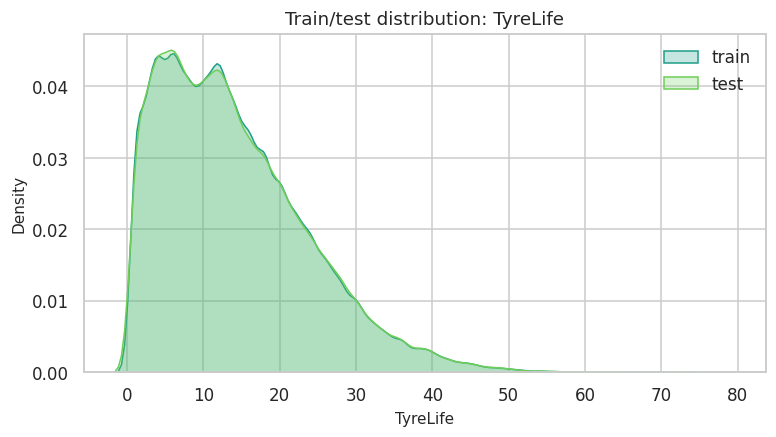

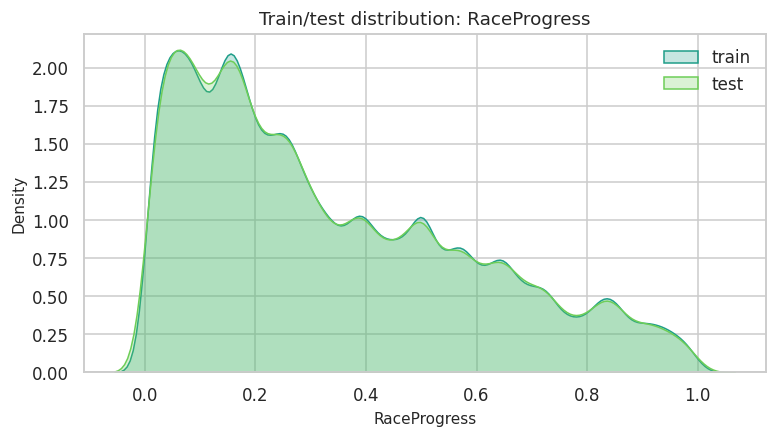

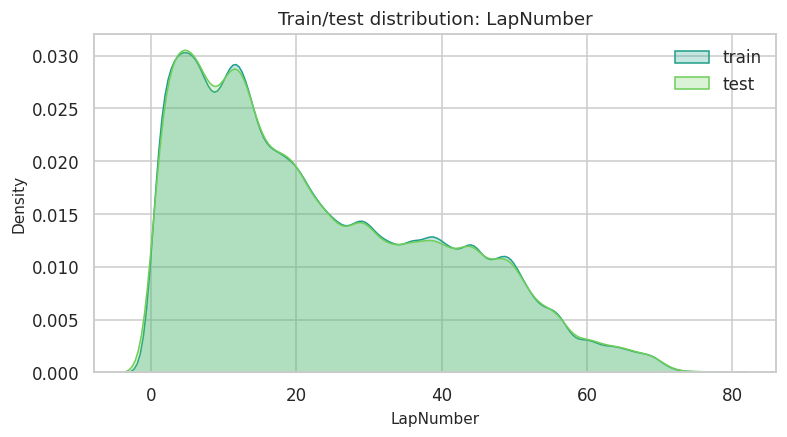

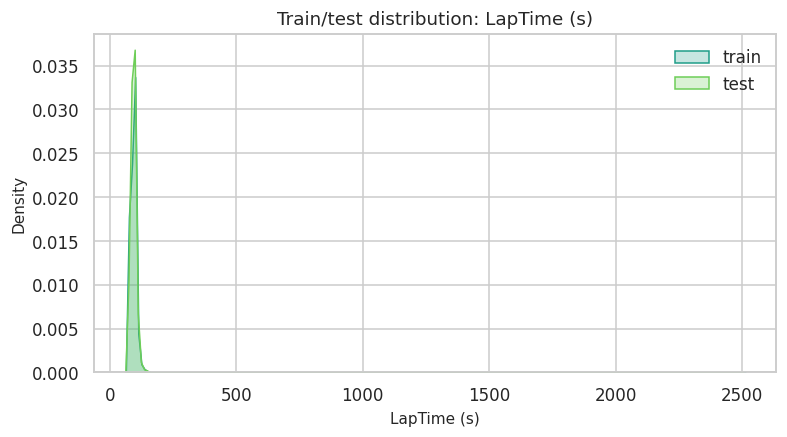

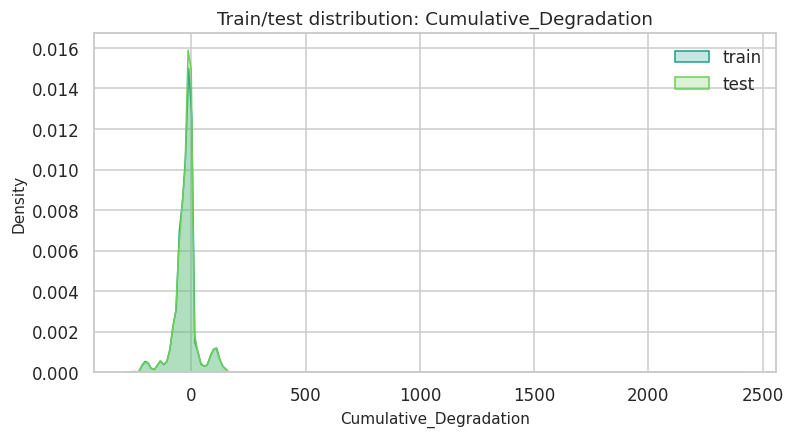

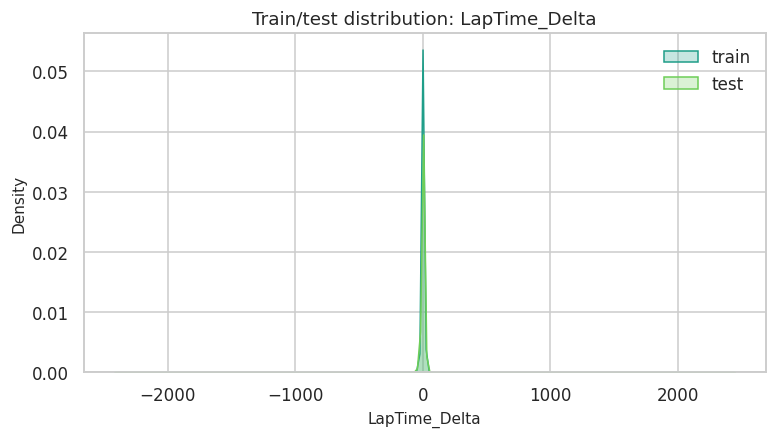

In [20]:
top_drift_cols = drift.head(6)["feature"].tolist()

for col in top_drift_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.kdeplot(train[col], label="train", fill=True, alpha=0.25, color=PRIMARY_COLOR, ax=ax)
    sns.kdeplot(test[col], label="test", fill=True, alpha=0.25, color=ACCENT_COLOR, ax=ax)
    ax.set_title(f"Train/test distribution: {col}")
    ax.legend()
    plt.show()


### 6.1 Drift Insights

The saved run shows very low numeric PSI values. The largest values are still tiny:

- `TyreLife`: about `0.00019`
- `RaceProgress`: about `0.00018`
- `LapNumber`: about `0.00016`

That suggests train and test are closely aligned numerically. The bigger practical risk is not broad train/test drift; it is leakage-like feature construction or validation that does not mimic the test distribution.


## 7. Feature Engineering Starter Set

This starter set uses only row-level information available in both train and test. It avoids target encoding here because target encoders need careful cross-validation to avoid leakage.

The competition notes say `Normalized_TyreLife` was removed. We should be careful with features that reconstruct it too directly. The engineered ratios below are included for exploration, but later model validation should decide whether they generalize.


In [21]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    eps = 1e-6
    
    if {"LapNumber", "RaceProgress"}.issubset(out.columns):
        out["EstimatedRaceLaps"] = out["LapNumber"] / out["RaceProgress"].clip(lower=eps)
        out["EstimatedLapsRemaining"] = out["EstimatedRaceLaps"] - out["LapNumber"]
        out["LapNumber_x_RaceProgress"] = out["LapNumber"] * out["RaceProgress"]
    
    if {"TyreLife", "LapNumber"}.issubset(out.columns):
        out["TyreLife_to_LapNumber"] = out["TyreLife"] / out["LapNumber"].clip(lower=eps)
    
    if {"TyreLife", "EstimatedRaceLaps"}.issubset(out.columns):
        out["TyreLife_to_EstimatedRaceLaps"] = out["TyreLife"] / out["EstimatedRaceLaps"].clip(lower=eps)
    
    if {"LapTime (s)", "LapTime_Delta"}.issubset(out.columns):
        out["LapTime_plus_Delta"] = out["LapTime (s)"] + out["LapTime_Delta"]
        out["AbsLapTime_Delta"] = out["LapTime_Delta"].abs()
    
    if {"Position", "Position_Change"}.issubset(out.columns):
        out["PreviousPositionApprox"] = out["Position"] - out["Position_Change"]
        out["AbsPosition_Change"] = out["Position_Change"].abs()
    
    if "Compound" in out.columns:
        out["IsSoft"] = (out["Compound"].astype(str) == "SOFT").astype("int8")
        out["IsMedium"] = (out["Compound"].astype(str) == "MEDIUM").astype("int8")
        out["IsHard"] = (out["Compound"].astype(str) == "HARD").astype("int8")
        out["IsWetOrIntermediate"] = out["Compound"].astype(str).isin(["WET", "INTERMEDIATE"]).astype("int8")
    
    return reduce_memory_usage(out)


train_fe = add_features(train)
test_fe = add_features(test)

new_cols = [c for c in train_fe.columns if c not in train.columns]
print("New features:", new_cols)
train_fe[new_cols].head()


New features: ['EstimatedRaceLaps', 'EstimatedLapsRemaining', 'LapNumber_x_RaceProgress', 'TyreLife_to_LapNumber', 'TyreLife_to_EstimatedRaceLaps', 'LapTime_plus_Delta', 'AbsLapTime_Delta', 'PreviousPositionApprox', 'AbsPosition_Change', 'IsSoft', 'IsMedium', 'IsHard', 'IsWetOrIntermediate']


,EstimatedRaceLaps,EstimatedLapsRemaining,LapNumber_x_RaceProgress,TyreLife_to_LapNumber,TyreLife_to_EstimatedRaceLaps,LapTime_plus_Delta,AbsLapTime_Delta,PreviousPositionApprox,AbsPosition_Change,IsSoft,IsMedium,IsHard,IsWetOrIntermediate
0,70.000000,20.000000,35.714287,0.780000,0.557143,70.926994,7.564000,3.0,5.0,0,0,1,0
1,78.000000,51.000000,9.346154,0.259259,0.089744,42.478001,32.617001,7.0,3.0,0,0,1,0
2,72.000000,13.000000,48.347221,0.372881,0.305556,63.404999,7.540000,10.0,3.0,0,0,1,0
3,25.999998,23.999998,0.153846,1.000000,0.076923,87.037003,7.324000,7.0,0.0,0,1,0,0
4,72.000000,46.000000,9.388888,0.230769,0.083333,116.843002,8.965000,-1.0,3.0,0,0,1,0


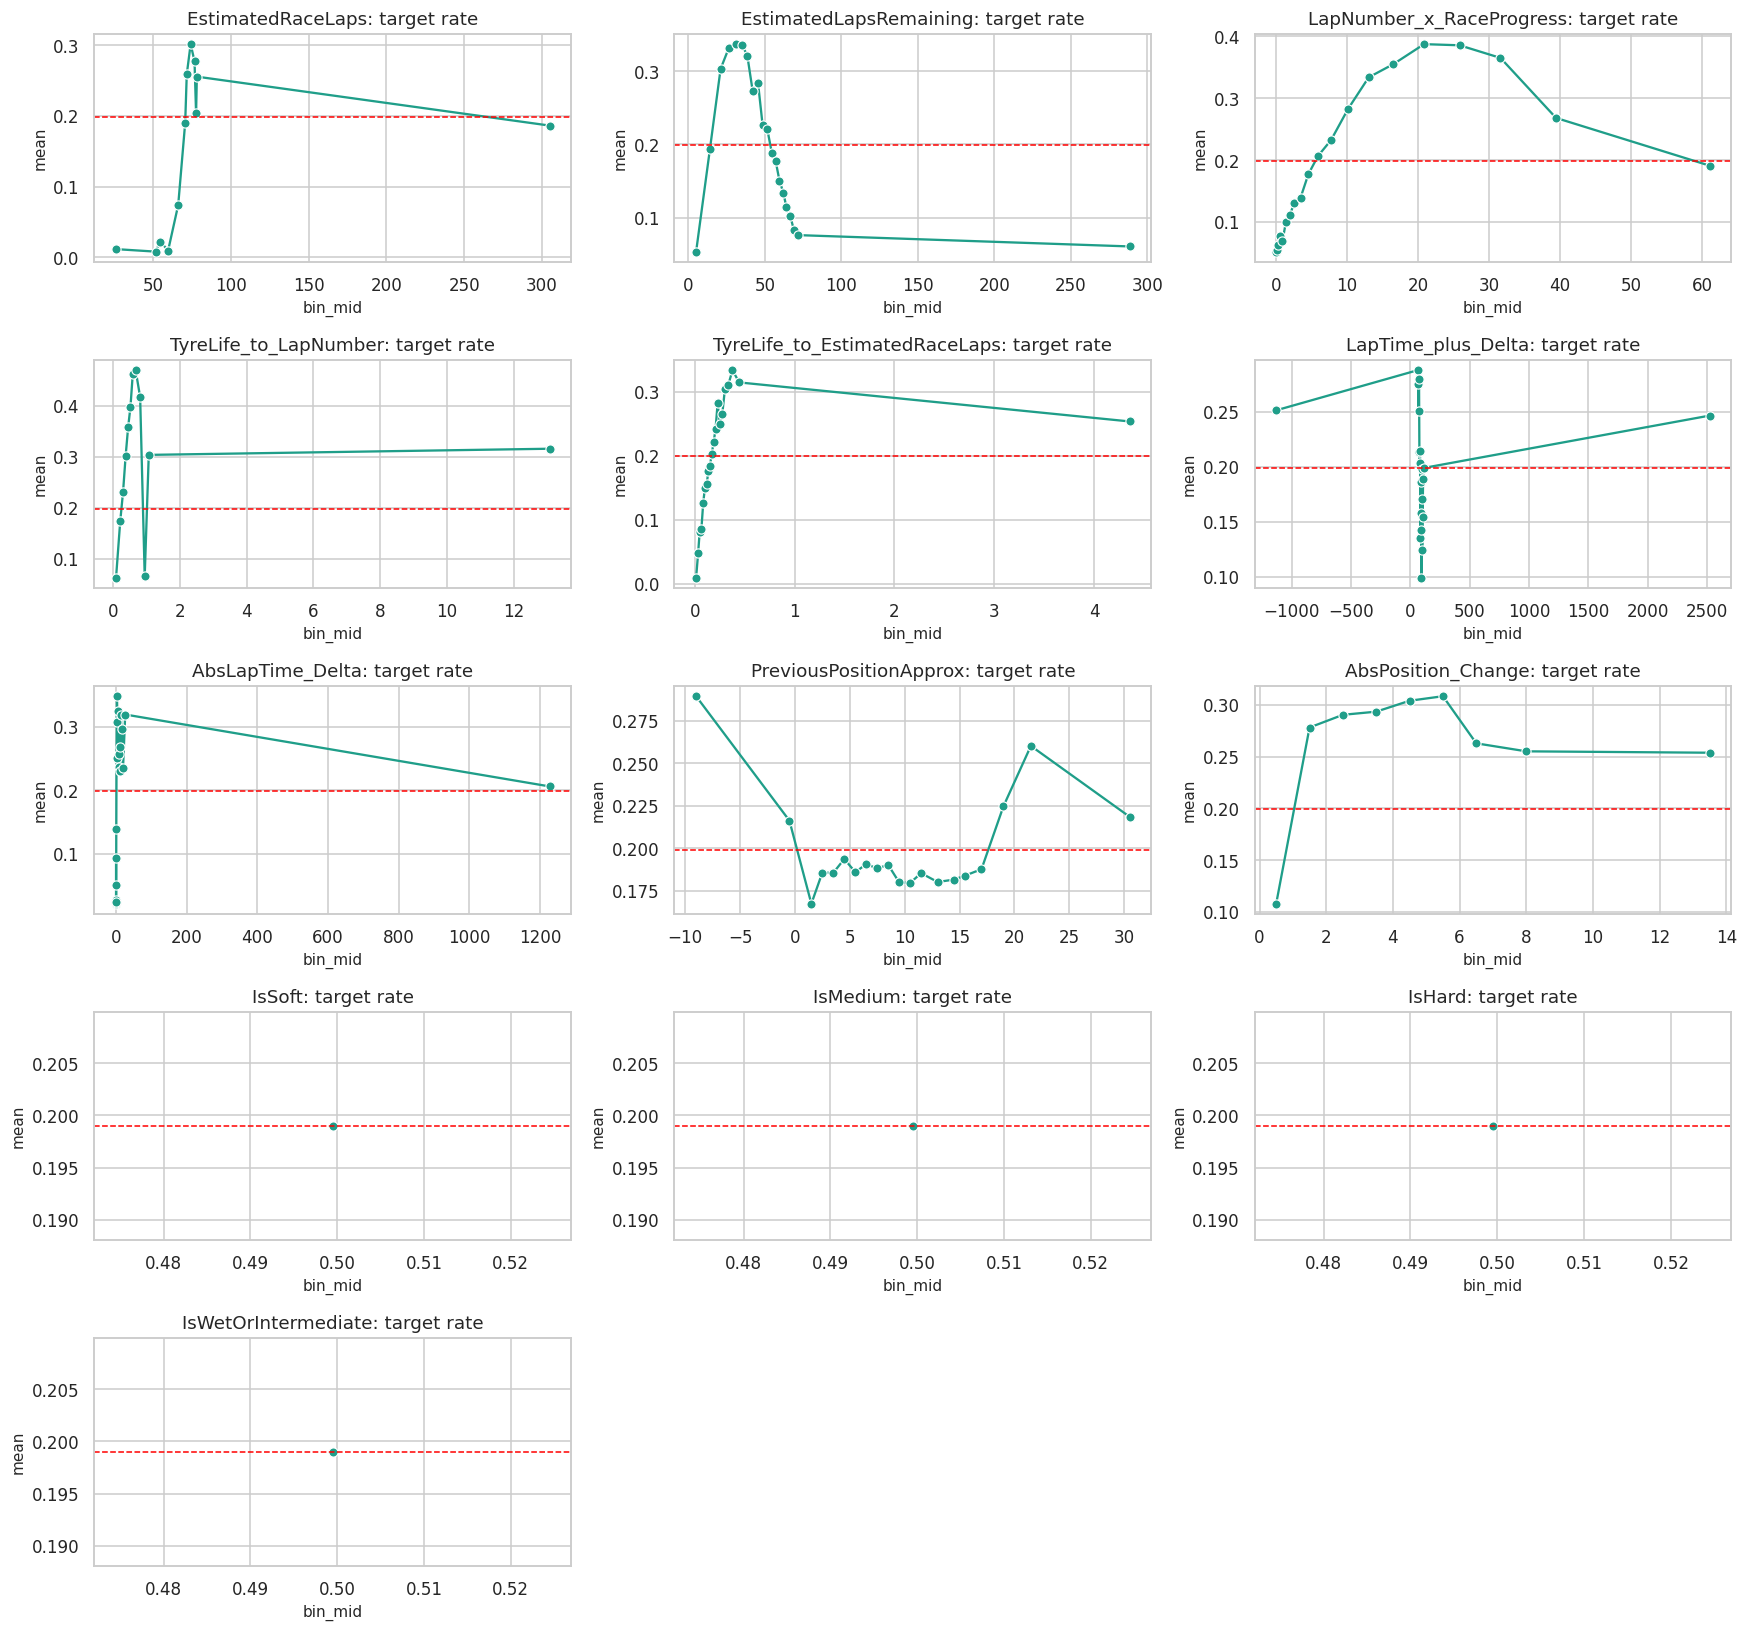

In [22]:
engineered_numeric = [c for c in new_cols if pd.api.types.is_numeric_dtype(train_fe[c])]

if engineered_numeric:
    n_cols = 3
    n_rows = int(np.ceil(len(engineered_numeric) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, max(4, 3 * n_rows)))
    axes = np.ravel(axes)
    
    for ax, col in zip(axes, engineered_numeric):
        rate_df = binned_target_rate(train_fe, col, TARGET, bins=20)
        sns.lineplot(data=rate_df, x="bin_mid", y="mean", marker="o", color=PRIMARY_COLOR, ax=ax)
        ax.axhline(train_fe[TARGET].mean(), color="red", linestyle="--", linewidth=1)
        ax.set_title(f"{col}: target rate")
    
    for ax in axes[len(engineered_numeric):]:
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()


## 8. Preprocessing Pipeline

This pipeline is intentionally simple and model-agnostic. Tree boosting libraries can often consume categoricals differently, but this scikit-learn pipeline is useful for baselines and for creating clean validation splits.


In [23]:
def make_onehot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse=True)


def make_preprocessor(df: pd.DataFrame, target: str = TARGET, id_col: str = ID_COL) -> tuple[ColumnTransformer, list[str], list[str]]:
    drop_cols = [target]
    # Keep id out of most models. It is sequential and usually not causal.
    if id_col in df.columns:
        drop_cols.append(id_col)
    
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]
    
    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder()),
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ],
        remainder="drop",
        sparse_threshold=0.3,
    )
    return preprocessor, num_cols, cat_cols


preprocessor, model_numeric_cols, model_categorical_cols = make_preprocessor(train_fe)
print(f"Model numeric columns ({len(model_numeric_cols)}): {model_numeric_cols}")
print(f"Model categorical columns ({len(model_categorical_cols)}): {model_categorical_cols}")


Model numeric columns (24): ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'EstimatedRaceLaps', 'EstimatedLapsRemaining', 'LapNumber_x_RaceProgress', 'TyreLife_to_LapNumber', 'TyreLife_to_EstimatedRaceLaps', 'LapTime_plus_Delta', 'AbsLapTime_Delta', 'PreviousPositionApprox', 'AbsPosition_Change', 'IsSoft', 'IsMedium', 'IsHard', 'IsWetOrIntermediate']
Model categorical columns (3): ['Driver', 'Compound', 'Race']


In [24]:
X = train_fe.drop(columns=[TARGET])
y = train_fe[TARGET].astype("int8")

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(X_train.shape, X_valid.shape)
print("train positive rate:", y_train.mean())
print("valid positive rate:", y_valid.mean())


(351312, 28) (87828, 28)
train positive rate: 0.19898267067450015
valid positive rate: 0.19897982420184906


In [25]:
# Fit preprocessing only on training fold to avoid validation leakage.
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

print("Processed train shape:", X_train_processed.shape)
print("Processed valid shape:", X_valid_processed.shape)


Processed train shape: (351312, 637)
Processed valid shape: (87828, 637)


## 9. Save Prepared Artifacts

These files are optional convenience outputs. For full modeling, it is usually better to recompute features inside each cross-validation fold.


In [26]:
try:
    train_fe.to_parquet(OUTPUT_DIR / "train_preprocessed.parquet", index=False)
    test_fe.to_parquet(OUTPUT_DIR / "test_preprocessed.parquet", index=False)
    saved_paths = [OUTPUT_DIR / "train_preprocessed.parquet", OUTPUT_DIR / "test_preprocessed.parquet"]
except Exception as exc:
    print(f"Parquet save failed ({exc}). Falling back to CSV.")
    train_fe.to_csv(OUTPUT_DIR / "train_preprocessed.csv", index=False)
    test_fe.to_csv(OUTPUT_DIR / "test_preprocessed.csv", index=False)
    saved_paths = [OUTPUT_DIR / "train_preprocessed.csv", OUTPUT_DIR / "test_preprocessed.csv"]

print("Saved:")
for path in saved_paths:
    print(path)


Saved:
/kaggle/working/train_preprocessed.parquet
/kaggle/working/test_preprocessed.parquet


### 9.1 Artifact Policy

Generated preprocessing artifacts are useful for Kaggle working sessions, but they usually should not be committed to GitHub because they are derived data and can become large. Keep source notebooks, code, and documentation in the repo; regenerate artifacts from the notebook when needed.

If a shareable package is needed, create a zip containing the source files rather than committing generated parquet/CSV outputs.


## 10. Notes for the Modeling Notebook

- Evaluation is likely probability-based, so optimize validation AUC/log loss depending on the competition metric.
- Use stratified folds because `PitNextLap` is imbalanced.
- Treat high-cardinality `Driver` carefully. One-hot is fine for linear baselines, while CatBoost or target encoding may help later.
- Check whether engineered tyre-life ratio features generalize. They may be powerful, but they can also overfit the synthetic generation process.
- Compare models with and without the original F1 strategy dataset only after this baseline EDA is stable.
